Загружаем датасет

In [251]:
import pandas as pd

df = pd.read_csv('student_lifestyle_100k.csv')
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Смотрим информацию по датасету. Видим, что null-значения отсутствуют.

In [252]:
#CGPA - успеваемость (0.0 - 4.0)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Пол и профиль обучения указаны строкой - лучше заменить на категории. Столбец Student_ID неинформативный - удаляем сразу.

Фильтруем, что суммарно в сутках не более 24 часов

In [253]:
df['Gender'] = df['Gender'].astype('category')
df['Department'] = df['Department'].astype('category')
df = df.drop('Student_ID', axis=1)
df = df[(df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours']) <= 24]

df.info()

<class 'pandas.DataFrame'>
Index: 99921 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 99921 non-null  int64   
 1   Gender              99921 non-null  category
 2   Department          99921 non-null  category
 3   CGPA                99921 non-null  float64 
 4   Sleep_Duration      99921 non-null  float64 
 5   Study_Hours         99921 non-null  float64 
 6   Social_Media_Hours  99921 non-null  float64 
 7   Physical_Activity   99921 non-null  int64   
 8   Stress_Level        99921 non-null  int64   
 9   Depression          99921 non-null  bool    
dtypes: bool(1), category(2), float64(4), int64(3)
memory usage: 6.4 MB


Проверяем наличие дубликатов. Видим, что они отсутствуют

In [254]:
print(df.duplicated().sum())

0


Смотрим статистику по столбцам.

Видим, что пол распределён достаточно равномерно, однако в
таргете (наличие депрессии) преобладает значение False.

Значит, при выборе данных нужно будет отфильтровать их так,
чтобы распределение значений в столбце Depression было
примерно поровну.

In [255]:
print(df["Depression"].value_counts(normalize=True))
print('----')
print(df["Gender"].value_counts(normalize=True))

Depression
False    0.89935
True     0.10065
Name: proportion, dtype: float64
----
Gender
Male      0.501176
Female    0.498824
Name: proportion, dtype: float64


Строим графики. Видим, что возраст, профиль обучения, академическая успеваемость
и физическая активность распределены достаточно равномерно. Также видим, что все столбцы принимают возможные значения.

Продолжительность сна и количество часов на учёбу и социальные сети же имеют выбросы.
Уровень стресса - распределение похоже на логнормальное.
Продолжительность сна и количество часов на учёбу и социальные сети - распределение похоже на нормальное.

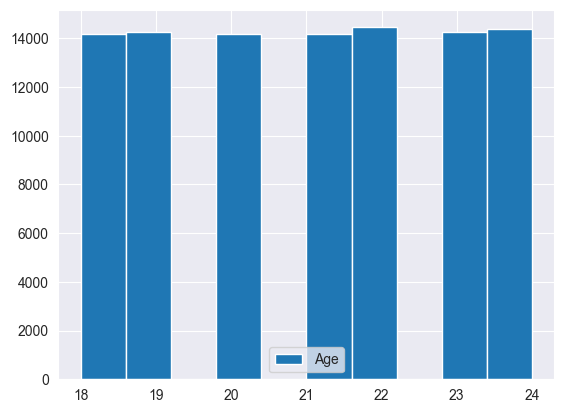

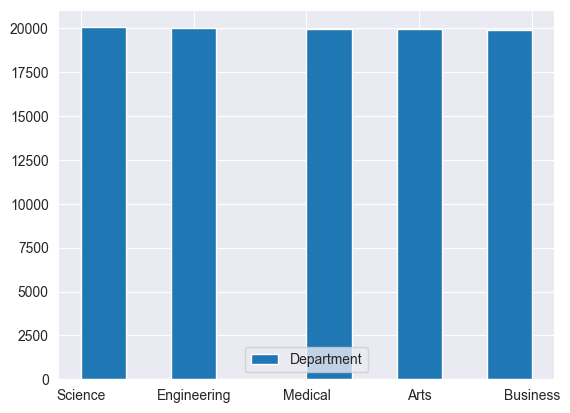

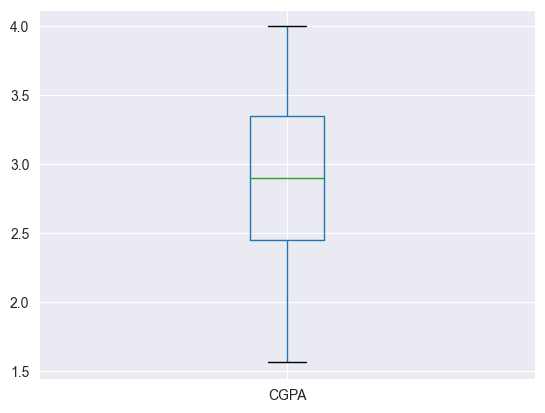

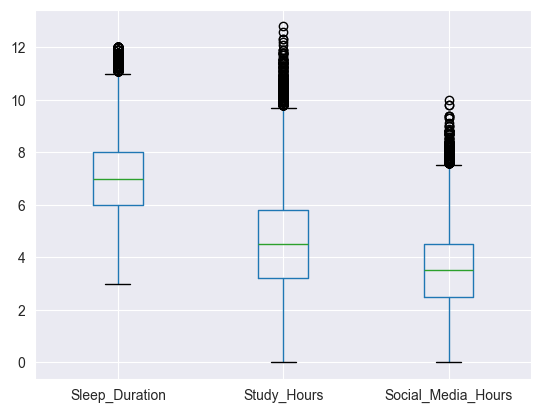

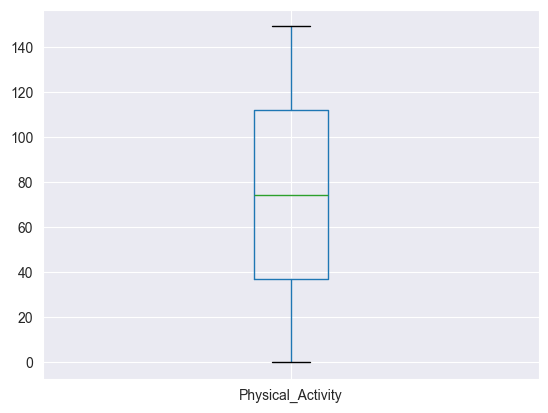

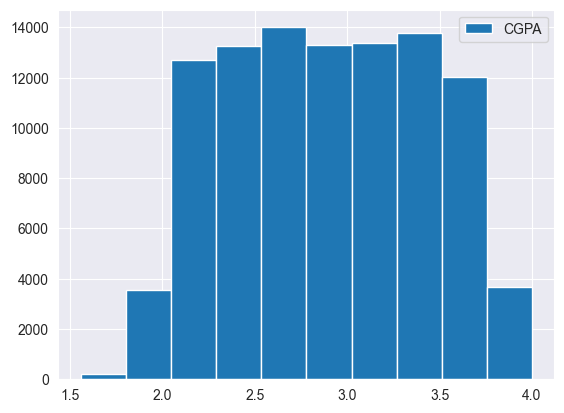

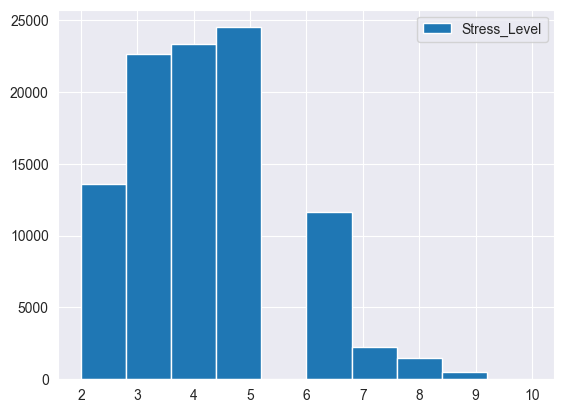

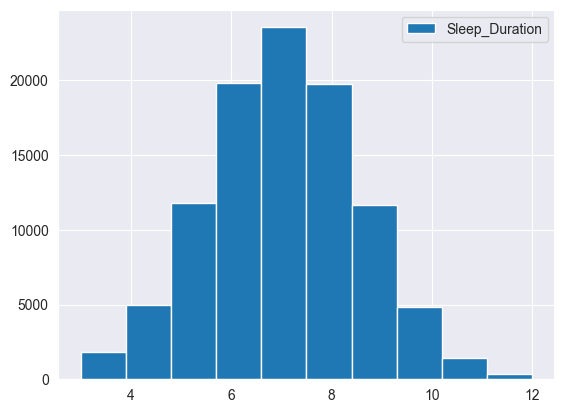

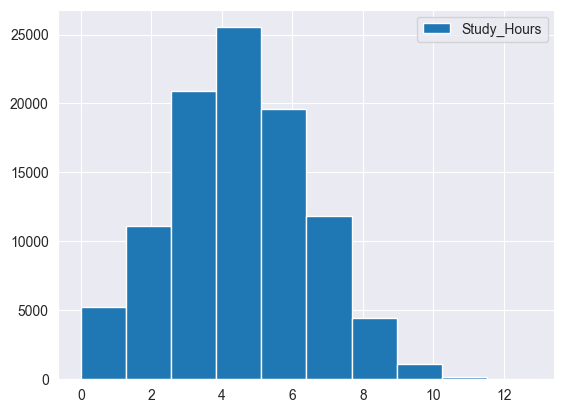

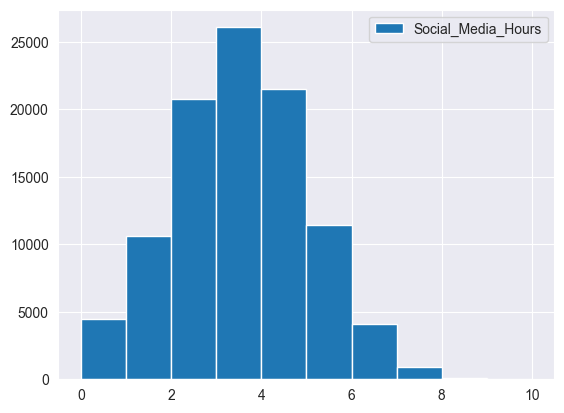

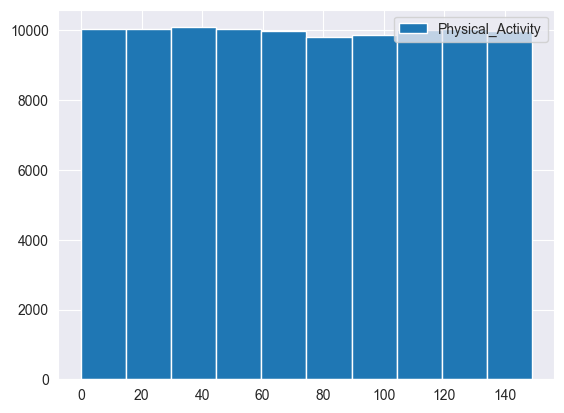

In [256]:
import matplotlib.pyplot as plt

df["Age"].hist(legend=["Age"])
plt.show()
df["Department"].hist(legend=["Department"])
plt.show()

df.boxplot(column=['CGPA'])
plt.show()
df.boxplot(column=['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours'])
plt.show()
df.boxplot(column=['Physical_Activity'])
plt.show()

df["CGPA"].hist(legend=["CGPA"])
plt.show()
df["Stress_Level"].hist(legend=["Stress Level"])
plt.show()
df["Sleep_Duration"].hist(legend=["Sleep_Duration"])
plt.show()
df["Study_Hours"].hist(legend=["Study_Hours"])
plt.show()
df["Social_Media_Hours"].hist(legend=["Social_Media_Hours"])
plt.show()
df["Physical_Activity"].hist(legend=["Physical_Activity"])
plt.show()

Смотрим по признакам долю студентов с депрессией при разных значениях признака.

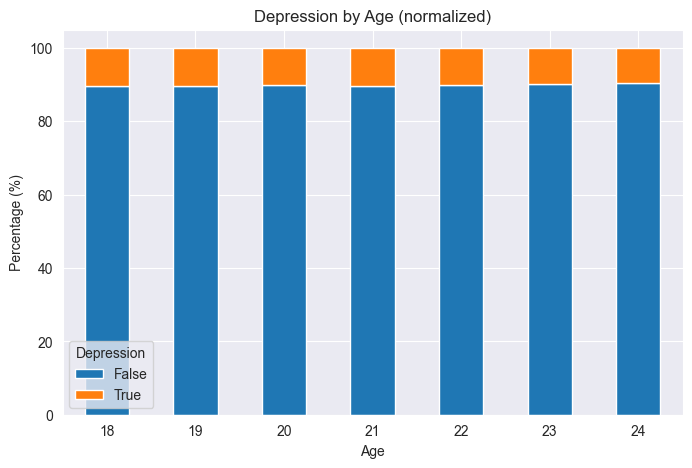

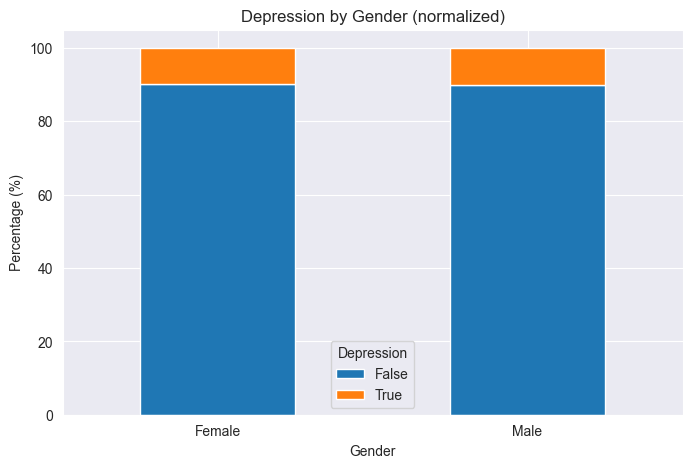

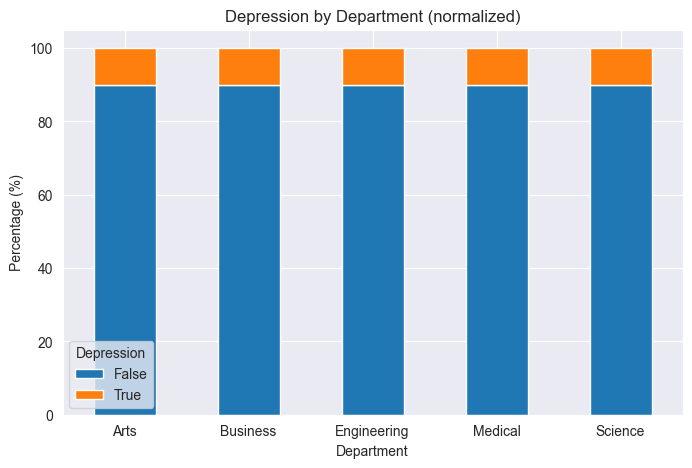

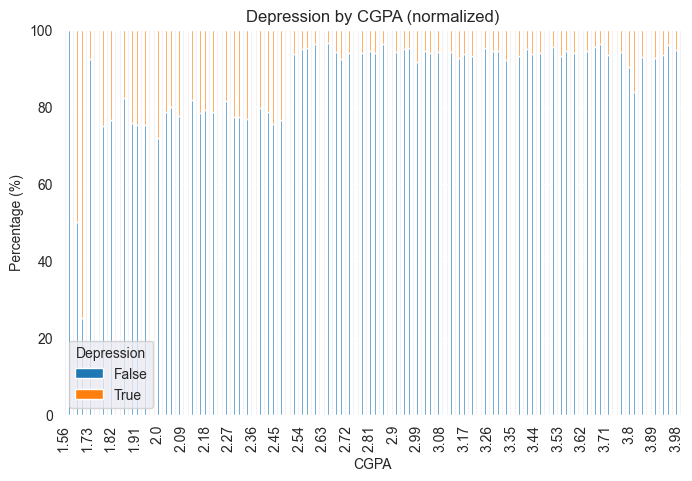

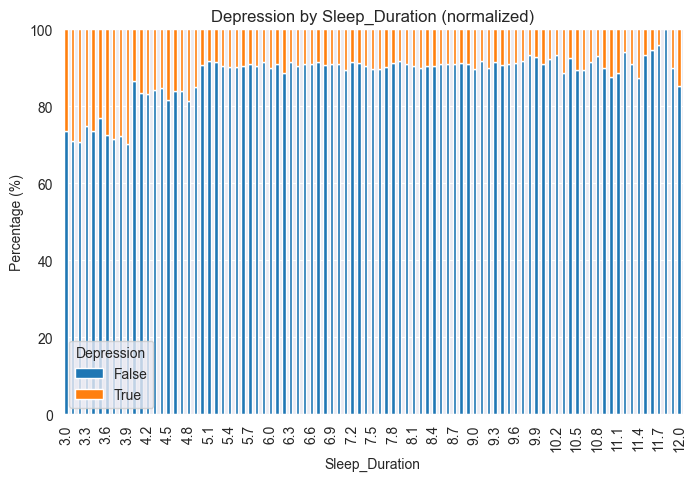

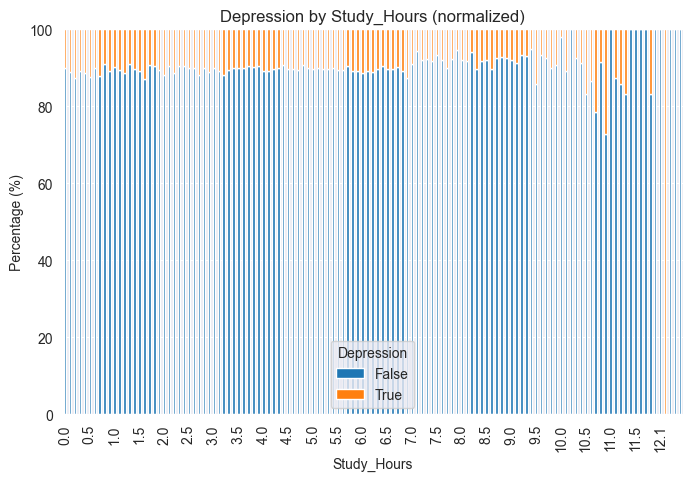

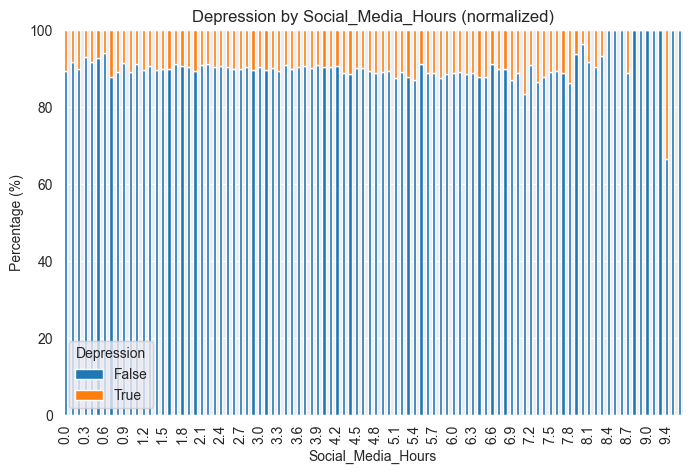

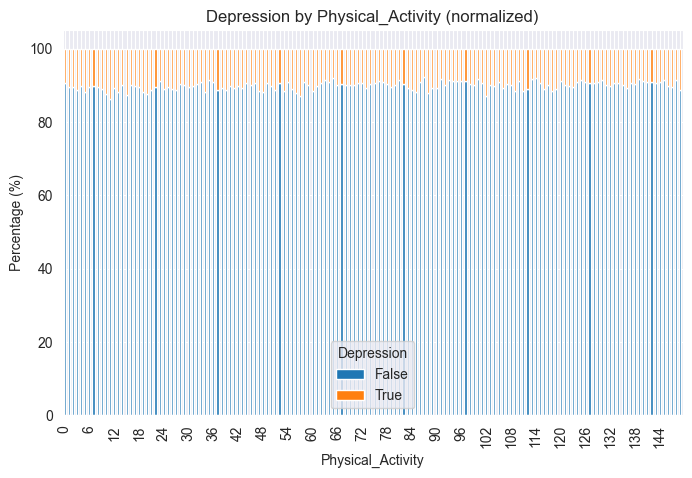

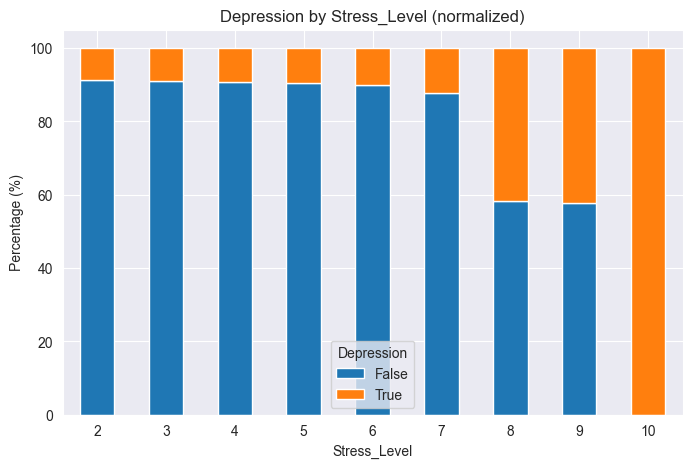

In [257]:
for elem in df.columns:
    if elem == "Depression":
        continue
    depression_by_elem = pd.crosstab(df[elem], df['Depression'], normalize='index') * 100

    # Построениt
    ax = depression_by_elem.plot(kind='bar', stacked=True, figsize=(8,5))
    plt.title(f'Depression by {elem} (normalized)')
    plt.ylabel('Percentage (%)')
    plt.xlabel(elem)
    plt.legend(title='Depression', labels=['False', 'True'])
    plt.xticks(rotation=0)
    if len(depression_by_elem) > 20:
        plt.xticks(rotation=90)
        all_positions = range(len(depression_by_elem))
        all_labels = depression_by_elem.index.tolist()
        step = len(depression_by_elem)// 25
        new_labels = [label if i % step == 0 else '' for i, label in enumerate(all_labels)]

        ax.set_xticks(all_positions)
        ax.set_xticklabels(new_labels)
        plt.show()

    plt.show()


Видим, что депрессия чаще встречается у тех, кто спит меньше 5 часов, а также тех, у кого уровень стресса 8 и больше.
Вводим исходя из этого новые булевые признаки: является ли низкой успеваемость, является ли количества сна недостаточным, является ли уровень стресса критическим

In [258]:
df["Is_sleep_under_normal"] = df["Sleep_Duration"] < 5
df["Is_stress_level_critical"] = df["Stress_Level"] >= 8

Строим heatmap по корреляции признаков. Видим, что сильно коррелирующих признаков нет,
оставляем для анализа все.

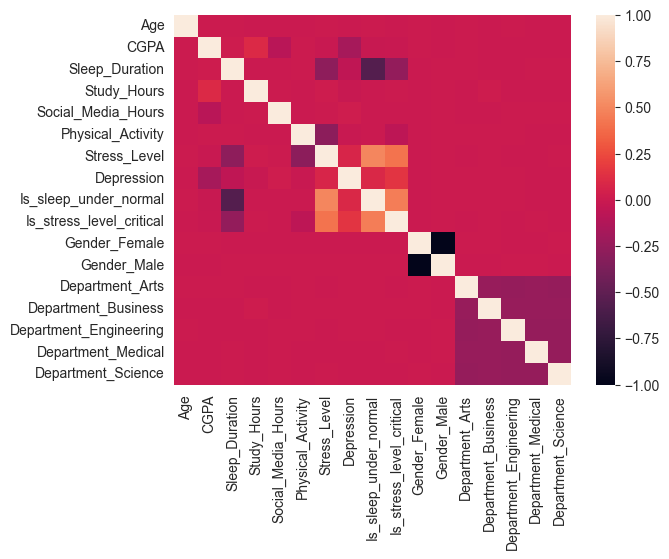

In [259]:
import seaborn as sns

df = pd.get_dummies(df, columns=['Gender', 'Department'])

sns.heatmap(df.corr())
plt.show()

Убираем выбросы

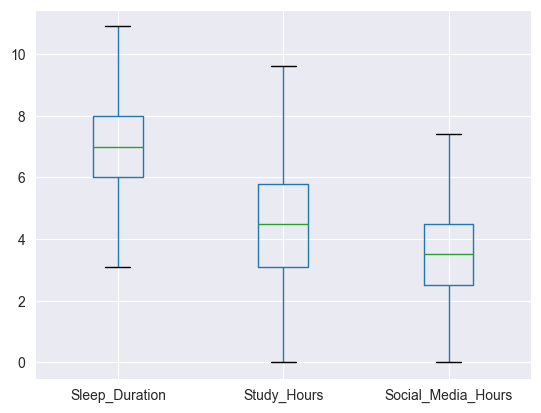

In [260]:
q_low = df['Sleep_Duration'].quantile(0.25)
q_hi = df['Sleep_Duration'].quantile(0.75)
q_range = q_hi - q_low
df = df[(df['Sleep_Duration'] < q_hi + 1.5 * q_range) & (df['Sleep_Duration'] > q_low - 1.5 * q_range)]

q_low = df['Study_Hours'].quantile(0.25)
q_hi = df['Study_Hours'].quantile(0.75)
q_range = q_hi - q_low
df = df[(df['Study_Hours'] < q_hi + 1.5 * q_range) & (df['Study_Hours'] > q_low - 1.5 * q_range)]

q_low = df['Social_Media_Hours'].quantile(0.25)
q_hi = df['Social_Media_Hours'].quantile(0.75)
q_range = q_hi - q_low
df = df[(df['Social_Media_Hours'] < q_hi + 1.5 * q_range) & (df['Social_Media_Hours'] > q_low - 1.5 * q_range)]

df.boxplot(column=['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours'])
plt.show()

Разбиваем данные на обучающую, валидационную и тестовую выборки для задачи прогнозирования CGPA

In [261]:
from sklearn.model_selection import train_test_split

X = df[['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours']]
y = df['CGPA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

На тестовой выборке масштабируем признаки, к остальным применяем .transform

In [262]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Обучаем линейную регрессию

In [263]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    loss='squared_error',
    penalty='l1',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.01,
    max_iter=500,
    tol=None,
    random_state=42
)
model.fit(X_train, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l1'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",500
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",None
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


Проверяем метрики

In [264]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Train:")
y_pred_train = model.predict(X_train)
print(f"MAE: {mean_absolute_error(y_train, y_pred_train)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"R²: {r2_score(y_train, y_pred_train)}")

print("Val:")
y_pred_val = model.predict(X_val)
print(f"MAE: {mean_absolute_error(y_val, y_pred_val)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val))}")
print(f"R²: {r2_score(y_val, y_pred_val)}")

Train:
MAE: 0.45491234142683296
RMSE: 0.5280283364767494
R²: 0.015916715416647742
Val:
MAE: 0.4558364835797725
RMSE: 0.5286284715806554
R²: 0.015087382429516905


Подбираем learning rate и количество эпох. Уменьшаем learninig rate

In [265]:
model = SGDRegressor(
    loss='squared_error',
    penalty='l1',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.001,
    max_iter=500,
    tol=None,
    random_state=42
)
model.fit(X_train, y_train)

print("Train:")
y_pred_train = model.predict(X_train)
print(f"MAE: {mean_absolute_error(y_train, y_pred_train)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"R²: {r2_score(y_train, y_pred_train)}")

print("Val:")
y_pred_val = model.predict(X_val)
print(f"MAE: {mean_absolute_error(y_val, y_pred_val)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val))}")
print(f"R²: {r2_score(y_val, y_pred_val)}")

Train:
MAE: 0.45474191108593437
RMSE: 0.5277504884751227
R²: 0.016952090289681587
Val:
MAE: 0.4555400625276698
RMSE: 0.5283482487013751
R²: 0.016131298573588637


In [266]:
model = SGDRegressor(
    loss='squared_error',
    penalty='l1',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.0001,
    max_iter=500,
    tol=None,
    random_state=42
)
model.fit(X_train, y_train)

print("Train:")
y_pred_train = model.predict(X_train)
print(f"MAE: {mean_absolute_error(y_train, y_pred_train)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"R²: {r2_score(y_train, y_pred_train)}")

print("Val:")
y_pred_val = model.predict(X_val)
print(f"MAE: {mean_absolute_error(y_val, y_pred_val)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val))}")
print(f"R²: {r2_score(y_val, y_pred_val)}")

Train:
MAE: 0.4546076956196588
RMSE: 0.5275930637776615
R²: 0.017538477007551845
Val:
MAE: 0.4555446951397624
RMSE: 0.5283177369704201
R²: 0.01624493071066313


Видим, что при уменьшении learning rate в 10 раз средняя ошибка мало уменьшается. Значит, дальше уменьшать неэффективно. Увеличиваем количество эпох

In [267]:
model = SGDRegressor(
    loss='squared_error',
    penalty='l1',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.0001,
    max_iter=750,
    tol=None,
    random_state=42
)
model.fit(X_train, y_train)

print("Train:")
y_pred_train = model.predict(X_train)
print(f"MAE: {mean_absolute_error(y_train, y_pred_train)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"R²: {r2_score(y_train, y_pred_train)}")

print("Val:")
y_pred_val = model.predict(X_val)
print(f"MAE: {mean_absolute_error(y_val, y_pred_val)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val))}")
print(f"R²: {r2_score(y_val, y_pred_val)}")

Train:
MAE: 0.45457270098815833
RMSE: 0.527592078139115
R²: 0.017542147833077837
Val:
MAE: 0.4556809156454619
RMSE: 0.5284393532231096
R²: 0.015791967022072306


In [268]:
model = SGDRegressor(
    loss='squared_error',
    penalty='l1',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.0001,
    max_iter=1000,
    tol=None,
    random_state=42
)
model.fit(X_train, y_train)

print("Train:")
y_pred_train = model.predict(X_train)
print(f"MAE: {mean_absolute_error(y_train, y_pred_train)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"R²: {r2_score(y_train, y_pred_train)}")

print("Val:")
y_pred_val = model.predict(X_val)
print(f"MAE: {mean_absolute_error(y_val, y_pred_val)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val))}")
print(f"R²: {r2_score(y_val, y_pred_val)}")

Train:
MAE: 0.4545856018145781
RMSE: 0.527613113275296
R²: 0.017463804933140703
Val:
MAE: 0.45565039893895676
RMSE: 0.5284474241273341
R²: 0.015761902987729615


Видим, что увеличение количества эпох не даёт значительного роста. Оставляем, как есть. Итоговая модель:

In [269]:
final_model = SGDRegressor(
    loss='squared_error',
    penalty='l1',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.0001,
    max_iter=1000,
    tol=None,
    random_state=42
)

Обучаем модель, смотрим метрики. Видим, что на разных выборках метрики остаются приблизительно одинаковыми.
В целом ошибка примерно в 0.5 балла, что для предсказания успеваемости неплохой результат. Однако R² около нуля, значит, предсказание работает не лучше среднего значения. Вероятнее всего это означает, что связь между успеваемостью и временем сна, учёбы и соцсетей слабая или нелинейная.

In [270]:
final_model.fit(X_train, y_train)

print("Train:")
y_pred_train = final_model.predict(X_train)
print(f"MAE: {mean_absolute_error(y_train, y_pred_train)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"R²: {r2_score(y_train, y_pred_train)}")

print("Val:")
y_pred_val = final_model.predict(X_val)
print(f"MAE: {mean_absolute_error(y_val, y_pred_val)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val))}")
print(f"R²: {r2_score(y_val, y_pred_val)}")

print("Test:")
y_pred_test = final_model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred_test)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test))}")
print(f"R²: {r2_score(y_test, y_pred_test)}")

Train:
MAE: 0.4545856018145781
RMSE: 0.527613113275296
R²: 0.017463804933140703
Val:
MAE: 0.45565039893895676
RMSE: 0.5284474241273341
R²: 0.015761902987729615
Test:
MAE: 0.4531414222519273
RMSE: 0.5261100790127089
R²: 0.014673623253485202


Смотрим коэффициенты фичей

In [271]:
feature_names = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours']
coefs = final_model.coef_[0]

# Создаём DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
}).sort_values('abs_coefficient', ascending=False)

print(importance_df)

              feature  coefficient  abs_coefficient
0      Sleep_Duration      0.01096          0.01096
1         Study_Hours      0.01096          0.01096
2  Social_Media_Hours      0.01096          0.01096


Видим, что все коэффициенты одинаковые и близки к нулю. Вероятнее всего, дело в том, что ни с каким из признаков нет связи или она нелинейная

Разбиваем данные на выборки и масштабируем численные признаки для задачи определения наличия депрессии.

In [272]:
X = df.drop('Depression', axis=1)
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

column_names_to_normalize = ["Age", "CGPA", "Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Physical_Activity",
                             "Stress_Level"]

scaler = StandardScaler()
scaler.fit(X_train[column_names_to_normalize])

X_train[column_names_to_normalize] = scaler.transform(X_train[column_names_to_normalize])
X_val[column_names_to_normalize] = scaler.transform(X_val[column_names_to_normalize])
X_test[column_names_to_normalize] = scaler.transform(X_test[column_names_to_normalize])

Обучаем Logistic Regression для определения, подвержен ли учащийся риску развития депрессии, исходя из его образа жизни и уровня стресса.

Сейчас распределение True/False у таргета примерно 10/90. У модели может появиться сильный перевес в сторону False, чтобы избежать этого, при обучении модели используем class_weight='balanced', чтобы веса классов были обратно пропорциональны их частоте.

In [273]:
from sklearn.linear_model import SGDClassifier

model = SGDClassifier(
    loss='log_loss',
    penalty='l1',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.01,
    max_iter=500,
    tol=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l1'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",500
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",None
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


В данном случае лучше ложно положительное предсказание, чем пропуск значения True, поэтому в качестве метрики лучше использовать recall.

In [274]:
from sklearn.metrics import recall_score

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
print(f"Train: {recall_train}")
print(f"Val:   {recall_val}")

Train: 0.6855014534883721
Val:   0.6773255813953488


Пробуем другие значения learning rate и числа эпох. Уменьшаем eta0

In [275]:
model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.001,
    max_iter=500,
    tol=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
print(f"Train: {recall_train}")
print(f"Val:   {recall_val}")

Train: 0.6707848837209303
Val:   0.6620639534883721


In [276]:
model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.0001,
    max_iter=500,
    tol=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
print(f"Train: {recall_train}")
print(f"Val:   {recall_val}")

Train: 0.6876816860465116
Val:   0.6853197674418605


In [277]:
model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.00001,
    max_iter=500,
    tol=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
print(f"Train: {recall_train}")
print(f"Val:   {recall_val}")

Train: 0.6925872093023255
Val:   0.6831395348837209


In [278]:
model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.000001,
    max_iter=500,
    tol=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
print(f"Train: {recall_train}")
print(f"Val:   {recall_val}")

Train: 0.6905886627906976
Val:   0.6809593023255814


Разница между recall на train и val небольшая - значит., переобучения нет. Видим, что рост recall от уменьшения eta0 в 10 раз стал небольшим - значит, нет смыла дальше уменьшать. Увеличиваем число эпох

In [279]:
model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.0001,
    max_iter=750,
    tol=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
print(f"Train: {recall_train}")
print(f"Val:   {recall_val}")

Train: 0.6914970930232558
Val:   0.684593023255814


In [280]:
model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.0001,
    max_iter=1000,
    tol=None,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
print(f"Train: {recall_train}")
print(f"Val:   {recall_val}")

Train: 0.6864098837209303
Val:   0.6838662790697675


Видим, что при количестве эпох 750 результат лучше, чем при 1000. Оставляем количество эпох 750. Итоговая модель:

In [281]:
final_model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    learning_rate='constant',
    eta0=0.0001,
    max_iter=750,
    tol=None,
    random_state=42,
    class_weight='balanced'
)

final_model.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",750
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",None
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Проверяем recall на train, val и test. Разница между показаниями метрики на разных выборках незначительная, значит, переобучения нет.
Recall около 0.7, значит, модель успешно обнаруживает примерно 70% студентов с депрессией. Это может говорить о недостаточности приведённых в датасете сведений для предсказания депрессии и влияние также и других факторов, не связанных с учёбой, соцсетями, сном и физической активностью, что соответствует реальной логике.

In [282]:
y_pred_train = final_model.predict(X_train)
y_pred_val = final_model.predict(X_val)
y_pred_test = final_model.predict(X_test)

recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
recall_test = recall_score(y_test, y_pred_test)
print(f"Train: {recall_train}")
print(f"Val:   {recall_val}")
print(f"Test:  {recall_test}")

Train: 0.6914970930232558
Val:   0.684593023255814
Test:  0.7009155645981688


Смотрим коэффициенты. Видим, что главным коэффициентом, влияющим на наличие депрессии, является то, достигает ли уровень стресса критического значения, на втором месте - академическая успеваемость (с отрицательным коэффициентом - риск депрессии выше у студентов с низкой успеваемостью). Остальные признаки же влияют незначительно.

In [283]:
feature_names = X_train.columns.tolist()
coefs = final_model.coef_[0]

# Создаём DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
}).sort_values('abs_coefficient', ascending=False)

print(importance_df)

                     feature  coefficient  abs_coefficient
8   Is_stress_level_critical     1.861858         1.861858
1                       CGPA    -0.615620         0.615620
15        Department_Science    -0.084499         0.084499
9              Gender_Female    -0.057994         0.057994
7      Is_sleep_under_normal     0.056143         0.056143
10               Gender_Male    -0.046029         0.046029
12       Department_Business     0.040075         0.040075
14        Department_Medical    -0.037459         0.037459
6               Stress_Level     0.033861         0.033861
2             Sleep_Duration    -0.033753         0.033753
0                        Age    -0.025054         0.025054
13    Department_Engineering    -0.017510         0.017510
4         Social_Media_Hours     0.006582         0.006582
11           Department_Arts    -0.004629         0.004629
3                Study_Hours    -0.003662         0.003662
5          Physical_Activity     0.001765         0.0017